Модели генерации поля:

1. **Гауссовский монохроматический источник** - эталон
2. **Стохастическая модель SERVAL**  - in progress
3. **Набор когерентных Гаусс-Шелл мод**  - in progress
4. **Метод сложения амплитуд** - in progress  

Апертуры:
1. Идеальная (круглая, прямоугольная) - эталон
2. Физические параметры (задание толщины, материала, неровностей) - in progress

```
Генерация источника → пропагация в свободном пространстве z1 → апертура → пропагаця в свободном пространстве z2
```

Вычисляются величины:
- интенсивность I(x,y)
- взаимная функция когерентности J(r₁,r₂)
- глобальная степень когерентности ζ
________
TODO:
- SERVAL не работает адекватно
- Корректная ли J(r₁,r₂) (выбрать какую-то одну нотацию)
- Корректно прописать полихромитичность, можно ли пренебречь длиной сгустка
- в отрисовку дописать расчет FWHM/RMS
- перенос задания физической апертуры


In [170]:
import numpy as np
import scipy.fft as sfft
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import copy
import time

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 14,
    'figure.figsize': (10, 4),
    'figure.dpi': 100,
})

Для стационарного случайного поля $E(\mathbf{r}, t)$ взаимная функция когерентности:

$$J(\mathbf{r}_1, \mathbf{r}_2) = \langle E^*(\mathbf{r}_1)\, E(\mathbf{r}_2) \rangle$$

угловые скобки - статистическое усреднение по ансамблю реализаций.  

$$J(\mathbf{r}, \mathbf{r}) = \langle |E(\mathbf{r})|^2 \rangle = I(\mathbf{r})$$ - интенсивность.

С нормировкой:

$$\mu(\mathbf{r}_1, \mathbf{r}_2) = \frac{J(\mathbf{r}_1,\mathbf{r}_2)}{\sqrt{I(\mathbf{r}_1)\,I(\mathbf{r}_2)}}$$

Интегральная степень когерентности

$$\zeta = \frac{\iint |J(\mathbf{r}_1,\mathbf{r}_2)|^2\, d\mathbf{r}_1\, d\mathbf{r}_2}{\left(\int I(\mathbf{r})\, d\mathbf{r}\right)^2}$$


Решение уравнения Гельмгольца для монохроматического поля:

$$\frac{\partial^2 E}{\partial z^2} + \nabla_{\perp}^2 E + k^2 E = 0$$

Передаточная функция свободного пространства (угловой спектр):

$$H(k_x, k_y; z) = \exp\!\left[i z \left(\sqrt{k^2 - k_x^2 - k_y^2}\right)\right]$$


In [171]:
class RadiationField:
    """
    Stores a (partially) coherent radiation field in 3-D grid (z, y, x).

    Parameters
    ----------
    shape : (Nz, Ny, Nx) int
    dgrid : (dx, dy, dz) float  [m]  transverse and longitudinal step
    xlamds : float  carrier wavelength [m]
    domain_z : 't' (time/longitudinal coordinate) or 'f' (frequency)
    domain_xy : transverse domain (s - space, k - inverse space)
    """

    def __init__(self, shape=(1, 121, 121), dgrid=(1e-6, 1e-6, 1e-6),
                 xlamds=1e-9, domain_z='t', domain_xy='s'):
        nz, ny, nx = shape
        self.fld = np.zeros((nz, ny, nx), dtype=np.complex128)
        self.fld_stat = []          # list of realization arrays
        self.dx, self.dy, self.dz = dgrid
        self.xlamds = xlamds
        self.domain_z = domain_z
        self.domain_xy = domain_xy

    # ---- basic size properties ----
    def Nx(self): return self.fld.shape[2]
    def Ny(self): return self.fld.shape[1]
    def Nz(self): return self.fld.shape[0]
    def Nstat(self): return len(self.fld_stat)

    def Lx(self): return self.Nx() * self.dx
    def Ly(self): return self.Ny() * self.dy
    def Lz(self): return self.Nz() * self.dz

    # ---- coordinate / frequency axes ----
    def scale_x(self):
        return (np.arange(self.Nx()) - self.Nx() // 2) * self.dx

    def scale_y(self):
        return (np.arange(self.Ny()) - self.Ny() // 2) * self.dy

    def scale_kx(self):
        return sfft.fftshift(sfft.fftfreq(self.Nx(), d=self.dx)) * 2 * np.pi

    def scale_ky(self):
        return sfft.fftshift(sfft.fftfreq(self.Ny(), d=self.dy)) * 2 * np.pi

    # ---- intensity ----
    def intensity(self):
        """Return intensity array (Nz, Ny, Nx) averaged over stat ensemble if available."""
        if len(self.fld_stat) > 0:
            I = np.zeros_like(self.fld, dtype=np.float64)
            for f in self.fld_stat:
                I += np.abs(f) ** 2
            return I / len(self.fld_stat)
        return np.abs(self.fld) ** 2#/np.max(np.abs(self.fld) ** 2)

    def int_xy(self):
        """Intensity in transverse plane averaged over z (or single slice)."""
        return self.intensity().mean(axis=0)

    def int_x(self):
        """1-D marginal intensity along x."""
        return self.int_xy().mean(axis=0)

    def int_y(self):
        """1-D marginal intensity along y."""
        return self.int_xy().mean(axis=1)

    # ---- domain transforms ----
    def fft_xy(self):
        """In-place FFT in transverse plane (toggle s <-> k) """
        for iz in range(self.Nz()):
            self.fld[iz] = sfft.fftshift(
                sfft.fft2(sfft.ifftshift(self.fld[iz])))
            # нормировка?
        if len(self.fld_stat) > 0:
            for idx, f in enumerate(self.fld_stat):
                for iz in range(self.Nz()):
                    f[iz] = sfft.fftshift(sfft.fft2(sfft.ifftshift(f[iz])))
                self.fld_stat[idx] = f
        self.domain_xy = 'k' if self.domain_xy == 's' else 's'

    def fft_z(self):
        """In-place FFT along z (toggle t <-> f)"""
        if self.domain_z == 't':
          self.fld = sfft.fftshift(
              sfft.fft(sfft.ifftshift(self.fld, axes=0), axis=0), axes=0)
          self.domain_z = 'f'
        else:
          self.fld = sfft.fftshift(
              sfft.ifft(sfft.ifftshift(self.fld, axes=0), axis=0), axes=0)
          self.domain_z == 't'

    def ifft_xy(self):
        """In-place IFFT in transverse plane (toggle k <-> s)"""
        for iz in range(self.Nz()):
            self.fld[iz] = sfft.fftshift(
                sfft.ifft2(sfft.ifftshift(self.fld[iz])))
        if len(self.fld_stat) > 0:
            for idx, f in enumerate(self.fld_stat):
                for iz in range(self.Nz()):
                    f[iz] = sfft.fftshift(sfft.ifft2(sfft.ifftshift(f[iz])))
                self.fld_stat[idx] = f
        self.domain_xy = 's' if self.domain_xy == 'k' else 'k'

    def to_domain(self, domains):
        """
        tranfers radiation to specified domains (domain_xy, domain_z)
        *domains is a string with two letters:
            ("t" or "f") and ("s" or "k")
        where
            't' (time); 'f' (frequency); 's' (space); 'k' (inverse space);

        e.g. 'sf', 'st', 'kf', 'kt'

        """
        assert len(domains) == 2
        tgt_xy, tgt_z = domains[0], domains[1]
        if tgt_xy != self.domain_xy:
            self.fft_xy()
        if tgt_z != self.domain_z:
            self.fft_z()

    # ---- free-space propagator ----
    def prop(self, z):

        """
        Propagate field by distance z [m] using angular spectrum method

        can handle wide spectrum
          (every slice in freq.domain is propagated
           according to its frequency)
        no kx**2+ky**2<<k0**2 limitation

        assumes no angular dispersion
        assumes narrow spectrum at center of xlamds

        z>0 -> forward direction
        """
        k0 = 2 * np.pi / self.xlamds
        kx = self.scale_kx()
        ky = self.scale_ky()
        KX, KY = np.meshgrid(kx, ky)
        K2 = KX**2 + KY**2
        # evanescent waves check
        #prop_mask = K2 < k0**2
        #Kz = np.where(prop_mask, np.sqrt(np.maximum(k0**2 - K2, 0.0)), 0.0)
        #H = np.where(prop_mask, np.exp(1j * z * (Kz - k0)), 0.0)
        H = np.exp(1j * z * (np.sqrt(k0 ** 2 - KX ** 2 - KY ** 2)-k0))
        was_s = self.domain_xy == 's'
        if was_s:
            self.fft_xy()

        # apply transfer function
        for iz in range(self.Nz()):
            self.fld[iz] *= H
        if len(self.fld_stat) > 0:
            for f in self.fld_stat:
                for iz in range(self.Nz()):
                    f[iz] *= H

        if was_s:
            self.ifft_xy()

    def mut_coh_func(self, norm=True):
        """
        Mutual intensity J(r1, r2) = <E*(r1) * E(r2)>
        Усреднение по ансамблю fld_stat если доступен, иначе по оси z.
        Соглашение: J[y1,x1,y2,x2] = <E*(r1)*E(r2)>  [Goodman / Ocelot]
        Возвращает shape (Ny, Nx, Ny, Nx).
        """
        Ny, Nx = self.Ny(), self.Nx()

        if len(self.fld_stat) > 0:
            J = np.zeros((Ny, Nx, Ny, Nx), dtype=np.complex128)
            for f in self.fld_stat:
                J += np.mean(
                    f[:, :, :, np.newaxis, np.newaxis].conj() *
                    f[:, np.newaxis, np.newaxis, :, :],
                    axis=0)
            J /= len(self.fld_stat)
        else:
            J = np.mean(
                self.fld[:, :, :, np.newaxis, np.newaxis].conj() *
                self.fld[:, np.newaxis, np.newaxis, :, :],
                axis=0)

        if norm:
            # I(r) = J(r,r) — диагональ
            I = np.abs(J[np.arange(Ny)[:, None], np.arange(Nx)[None, :],
                        np.arange(Ny)[:, None], np.arange(Nx)[None, :]]) + 1e-30
            J /= np.sqrt(I[:, :, np.newaxis, np.newaxis] *
                        I[np.newaxis, np.newaxis, :, :])
        return J


    def csd(self, norm=True):
        """
        Cross-Spectral Density W(r1, r2; omega) = <E_tilde*(r1,w) * E_tilde(r2,w)>
        Усреднение по ансамблю fld_stat.
        Требует domainz == 'f' (или переводит автоматически во временную копию).
        Возвращает shape (Nz, Ny, Nx, Ny, Nx) — для каждой частоты.
        """
        import copy
        Ny, Nx, Nz = self.Ny(), self.Nx(), self.Nz

        dfl_f = copy.deepcopy(self)
        if dfl_f.domainz == 't':
            dfl_f.fftz()

        if len(dfl_f.fld_stat) > 0:
            W = np.zeros((Nz, Ny, Nx, Ny, Nx), dtype=np.complex128)
            for f in dfl_f.fld_stat:
                W += (f[:, :, :, np.newaxis, np.newaxis].conj() *
                      f[:, np.newaxis, np.newaxis, :, :])
            W /= len(dfl_f.fld_stat)
        else:
            W = (dfl_f.fld[:, :, :, np.newaxis, np.newaxis].conj() *
                dfl_f.fld[:, np.newaxis, np.newaxis, :, :])

        if norm:
            # S(r; w) = W(r,r;w) — спектральная плотность
            S = np.abs(W[:, np.arange(Ny)[:, None], np.arange(Nx)[None, :],
                          np.arange(Ny)[:, None], np.arange(Nx)[None, :]]) + 1e-30
            W /= np.sqrt(S[:, :, :, np.newaxis, np.newaxis] *
                        S[:, np.newaxis, np.newaxis, :, :])
        return W

    def intensity_ensemble(self):
        """
        I(r) = <|E(r)|^2> по ансамблю fld_stat или по fld, если ансамбля нет.
        Возвращает (Ny, Nx).
        """
        Ny, Nx = self.Ny(), self.Nx()
        if len(self.fld_stat) > 0:
            I = np.zeros((Ny, Nx), dtype=np.float64)
            for f in self.fld_stat:
                I += np.abs(f[0])**2
            return I / len(self.fld_stat)
        return np.abs(self.fld[0])**2

    def mut_coh_diff(self, norm=True):
        """
        J(Δr) — взаимная интенсивность в разностных координатах:
            J(Δr) = F^{-1}{ |F{E(r)}|^2 } (усреднённый по ансамблю).
        Возвращает (Ny, Nx) с Δx, Δy по scale_x/scale_y.
        """
        Ny, Nx = self.Ny(), self.Nx()

        if len(self.fld_stat) > 0:
            J_diff = np.zeros((Ny, Nx), dtype=np.complex128)
            for f in self.fld_stat:
                Ek = np.fft.fft2(f[0])
                J_diff += np.fft.ifft2(np.abs(Ek)**2)
            J_diff /= len(self.fld_stat)
        else:
            Ek = np.fft.fft2(self.fld[0])
            J_diff = np.fft.ifft2(np.abs(Ek)**2)

        J_diff = np.fft.fftshift(J_diff)
        if norm:
            J_max = np.abs(J_diff).max() + 1e-30
            J_diff /= J_max
        return J_diff

    def global_coherence(self):
        """
        ζ по Vartanyants & Singer (дискретно):
            ζ = sum_{r1,r2} |J(r1,r2)|^2 / (sum_r I(r))^2
        Числитель выражен через mut_coh_diff по теореме Парсеваля.
        """
        Ny, Nx = self.Ny(), self.Nx()

        # I(r) из ансамбля
        I = self.intensity_ensemble()
        I_sum = np.sum(I)

        # J(Δr) = mut_coh_diff(norm=False)
        J_diff = self.mut_coh_diff(norm=False)
        # sum |J(r1,r2)|^2 = sum |J(Δr)|^2 (с точностью до общей константы)
        num = np.sum(np.abs(J_diff)**2)

        denom = I_sum**2 + 1e-30
        return float(num / denom)

    def copy_params(self, other):
        """Copy grid/wavelength parameters from another RadiationField."""
        self.dx = other.dx
        self.dy = other.dy
        self.dz = other.dz
        self.xlamds = other.xlamds
        self.domain_z = other.domain_z
        self.domain_xy = other.domain_xy


def propagate_free_space(dfl, z):
    """
    Propagate RadiationField by distance z [m] using angular spectrum method.

    Handles both single-field (fld) and statistical ensemble (fld_stat).
    Returns a new RadiationField (does not modify in-place).

    Parameters
    ----------
    dfl : RadiationField  (domain_xy must be 's')
    z   : float  propagation distance [m]

    Returns
    -------
    RadiationField  propagated copy
    """
    dfl_out = copy.deepcopy(dfl)
    if dfl_out.domain_xy != 's':
        dfl_out.ifft_xy()
    dfl_out.prop(z)
    return dfl_out


## Функции отрисовки

In [180]:
def _extent_um(dfl):
  x = dfl.scale_x() * 1e6
  y = dfl.scale_y() * 1e6
  return x, y, [x[0], x[-1], y[0], y[-1]]


def plot_field(dfl, title=''):
  """
  |E(r)| и arg E(r), где E(r) = <E> по ансамблю.
  """
  Ny, Nx = dfl.Ny(), dfl.Nx()
  if len(dfl.fld_stat) > 0:
      E = np.zeros((Ny, Nx), dtype=np.complex128)
      for f in dfl.fld_stat:
          E += f[0]
      E /= len(dfl.fld_stat)
  else:
      E = dfl.fld[0]

  x, y, extent = _extent_um(dfl)

  fig, axes = plt.subplots(1, 2, figsize=(12, 5))
  if title:
      fig.suptitle(title)

  im0 = axes[0].imshow(np.abs(E), origin='lower', extent=extent,
                        cmap='inferno', aspect='equal')
  axes[0].set_title(r'$|E(\mathbf{r})|$')
  axes[0].set_xlabel('x, um')
  axes[0].set_ylabel('y, um')
  plt.colorbar(im0, ax=axes[0])

  im1 = axes[1].imshow(np.angle(E), origin='lower', extent=extent,
                        cmap='twilight', aspect='equal',
                        vmin=-np.pi, vmax=np.pi)
  axes[1].set_title(r'$\arg E(\mathbf{r})$')
  axes[1].set_xlabel('x, um')
  axes[1].set_ylabel('y, um')
  cbar = plt.colorbar(im1, ax=axes[1])
  cbar.set_ticks([-np.pi, 0, np.pi])
  cbar.set_ticklabels([r'$-\pi$', r'$0$', r'$\pi$'])

  plt.tight_layout()
  plt.show()


def plot_intensity(dfl, title=''):
  """
  I(r) = <|E(r)|^2>, использует dfl.intensity_ensemble().
  """
  I = dfl.intensity_ensemble()
  x, y, extent = _extent_um(dfl)

  fig, ax = plt.subplots(figsize=(7, 6))
  if title:
      ax.set_title(title)

  im = ax.imshow(I, origin='lower', extent=extent,
                  cmap='inferno', aspect='equal')
  ax.set_xlabel('x, um')
  ax.set_ylabel('y, um')
  plt.colorbar(im, ax=ax, label=r'$I(\mathbf{r})$, a.u.')
  plt.tight_layout()
  plt.show()


def plot_coherence(dfl, title=''):
  """
  |J(Δr)|, где J(Δr) = dfl.mut_coh_diff().
  Ничего не пересчитывает — берёт только из методов класса.
  """
  J_diff = dfl.mut_coh_diff(norm=True)
  x, y, extent = _extent_um(dfl)

  zeta = dfl.global_coherence()

  fig, ax = plt.subplots(figsize=(7, 6))
  full_title = (title + '  ' if title else '') + \
                rf'$\zeta={zeta:.4f}$'
  ax.set_title(full_title)

  im = ax.imshow(np.abs(J_diff), origin='lower', extent=extent,
                  cmap='hot', aspect='equal', vmin=0, vmax=1)
  ax.set_xlabel(r'$\Delta x$, um')
  ax.set_ylabel(r'$\Delta y$, um')
  plt.colorbar(im, ax=ax, label=r'$|J(\Delta\mathbf{r})|$ (норм.)')

  plt.tight_layout()
  plt.show()

def plot_spectrum(dfl, title=''):
  """
  1) Спектральные веса мод (по мощности каждой моды).
  2) Угловой спектр |FFT(E)|^2, усреднённый по ансамблю.
  """
  fld_stat = dfl.fld_stat
  Ny, Nx = dfl.Ny(), dfl.Nx()

  fig, axes = plt.subplots(1, 2, figsize=(13, 5))
  if title:
      fig.suptitle(title)

  # 1) Мощность мод
  if len(fld_stat) > 0:
      powers = np.array([np.sum(np.abs(f[0])**2) for f in fld_stat])
      powers /= powers.max() + 1e-30
      axes[0].bar(np.arange(len(fld_stat)), powers, color='steelblue', width=0.8)
      axes[0].set_xlabel('Индекс моды')
      axes[0].set_ylabel('Мощность (норм.)')
      axes[0].set_title('Спектр мод (по мощности)')
  else:
      axes[0].text(0.5, 0.5, 'Нет fld_stat\n(одна мода)',
                    ha='center', va='center', transform=axes[0].transAxes)
      axes[0].set_title('Спектр мод')

  # 2) Угловой спектр
  if len(fld_stat) > 0:
      Ik = np.zeros((Ny, Nx), dtype=np.float64)
      for f in fld_stat:
          Ek = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(f[0])))
          Ik += np.abs(Ek)**2
      Ik /= len(fld_stat)
  else:
      Ek = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(dfl.fld[0])))
      Ik = np.abs(Ek)**2

  kx = np.fft.fftshift(np.fft.fftfreq(Nx, d=dfl.dx))*1e-3  # mm⁻1
  ky = np.fft.fftshift(np.fft.fftfreq(Ny, d=dfl.dy))*1e-3
  extent_k = [kx[0], kx[-1], ky[0], ky[-1]]

  im = axes[1].imshow(Ik / (Ik.max() + 1e-30), origin='lower',
                      extent=extent_k, cmap='inferno', aspect='equal',
                      vmin=0, vmax=1)
  axes[1].set_title(r'Угловой спектр $|\tilde{E}(k_x,k_y)|^2$')
  axes[1].set_xlabel(r'$k_x$, mm$^{-1}$')
  axes[1].set_ylabel(r'$k_y$, mm$^{-1}$')
  plt.colorbar(im, ax=axes[1])

  plt.tight_layout()
  plt.show()

## Генерация излучения

### Параметры источника

| Параметр | Обозначение | Значение (уточнить!) |
|---|---|---|
| Горизонтальный размер пучка | $\sigma_x$ | 34 мкм |
| Вертикальный размер пучка | $\sigma_y$ | 12 мкм |
| Горизонтальная угловая расходимость | $\sigma_{x'}$ | 17 мкм рад |
| Вертикальная угловая расходимость | $\sigma_{y'}$ | 17 мкм рад |
| Горизонтальный эмиттанс | $\varepsilon_x = \sigma_x \sigma_{x'}$ | ~0.6 нм·рад |
| Вертикальный эмиттанс | $\varepsilon_y = \sigma_y \sigma_{y'}$ | ? |


### 1. Гауссовский монохроматический источник

Идеальный полностью когерентный гауссовский пучок. Поперечное поле в перетяжке:

$$E(x,y) = A \exp\!\left(-\frac{x^2+y^2}{4\,w^2}\right)$$


In [173]:
def generate_gaussian_source(xlamds, shape, dgrid, sigma_xy,
                              n_modes=1, delta_lambda=None, seed=42):
    """
    Полихроматический гауссов источник как набор монохроматических мод.

    Parameters
    ----------
    xlamds      : float  центральная длина волны [м]
    shape       : (1, Ny, Nx)  — Nz=1 (нет импульса)
    dgrid       : (dx, dy, dz)
    sigma_xy    : float  поперечный RMS размер поля [м]
    n_modes     : int    число спектральных мод
    delta_lambda: float или None
        None         → все моды с равными весами
        float        → гауссов спектр, sigma_lambda = xlamds / delta_lambda
                       (delta_lambda = lambda/delta_lambda — спектральное разрешение)
    seed        : int

    Returns
    -------
    RadiationField  с fld_stat заполненным модами
    """
    assert shape[0] == 1, "Nz должен быть 1 для квазимонохроматического источника"

    nz, ny, nx = shape
    dx, dy, dz = dgrid

    x = (np.arange(nx) - nx // 2) * dx
    y = (np.arange(ny) - ny // 2) * dy
    X, Y = np.meshgrid(x, y)

    rng = np.random.default_rng(seed)

    # --- спектральные длины волн и веса ---
    if n_modes == 1:
        lambdas = np.array([xlamds])
        weights = np.array([1.0])
    else:
        # равномерно распределены вокруг xlamds в диапазоне ±3*sigma_lambda
        if delta_lambda is not None:
            sigma_lambda = xlamds / delta_lambda
        else:
            sigma_lambda = xlamds * 0.01   # 1% по умолчанию если не задано
        lambdas = np.linspace(xlamds - 3*sigma_lambda,
                              xlamds + 3*sigma_lambda, n_modes)
        if delta_lambda is not None:
            # гауссов спектр
            weights = np.exp(-(lambdas - xlamds)**2 / (2 * sigma_lambda**2))
        else:
            # плоский спектр
            weights = np.ones(n_modes)
        weights /= weights.sum()

    dfl = RadiationField(shape=shape, dgrid=dgrid, xlamds=xlamds,
                         domain_z='t', domain_xy='s')

    for lam, w in zip(lambdas, weights):
        # поперечный гауссов профиль для данной длины волны
        E_xy = np.exp(-(X**2 + Y**2) / (4 * sigma_xy**2)).astype(np.complex128)
        # случайная глобальная фаза — моды некогерентны между собой
        phase = rng.uniform(0, 2 * np.pi)
        E_xy *= np.exp(1j * phase) * np.sqrt(w)

        field = np.zeros((1, ny, nx), dtype=np.complex128)
        field[0] = E_xy
        dfl.fld_stat.append(field)

    # fld = среднее по ансамблю (для совместимости)
    dfl.fld = np.mean(np.array(dfl.fld_stat), axis=0)

    # нормировка: по максимуму амплитуды среди всех мод
    E_max = max(np.abs(f).max() for f in dfl.fld_stat)
    if E_max > 0:
        dfl.fld_stat = [f / E_max for f in dfl.fld_stat]
        dfl.fld = dfl.fld / E_max

    return dfl

### Модель SERVAL

SERVAL генерирует реализации частично когерентного поля на основе стохастического подхода.

**Алгоритм:**
1. Генерация комплексного гауссовского белого шума $\xi(x,y)$
2. Умножение на огибающую пучка: $E'(x,y) = \xi(x,y) \cdot A(x,y)$,  
   где $A(x,y) = \exp(-(x^2/4\sigma_x^2 + y^2/4\sigma_y^2))$
3. Переход в $k$-пространство: $\tilde{E}'(k_x,k_y) = \mathcal{F}[E']$
4. Умножение на угловое распределение поворотного магнита (Гаусс с $\sigma_{\rm ang} \approx 1/\gamma$):
   $\tilde{E}''(k_x,k_y) = \tilde{E}' \cdot B(k_x,k_y)$
5. Обратное преобразование Фурье: $E_{\rm out} = \mathcal{F}^{-1}[\tilde{E}'']$


- Vartanyants I.A. & Singer A. *New J. Phys.* **12**, 035004 (2010)  
- Geloni G. et al. *Optics Comm.* **276**, 167 (2007)


In [174]:
def generate_serval(xlamds, shape, dgrid, sig_x, sig_y, sig_xp, sig_yp,
                    n_modes=50, delta_lambda=None, seed=42):
    """
    SERVAL для квазимонохроматического источника.
    Каждая мода — независимая реализация с длиной волны из спектра.
    """
    assert shape[0] == 1, "Nz=1 для квазимонохроматического источника"

    nz, ny, nx = shape
    dx, dy, dz = dgrid
    k0 = 2 * np.pi / xlamds

    x = (np.arange(nx) - nx // 2) * dx
    y = (np.arange(ny) - ny // 2) * dy
    X, Y = np.meshgrid(x, y)

    kx = sfft.fftshift(sfft.fftfreq(nx, d=dx)) * 2 * np.pi
    ky = sfft.fftshift(sfft.fftfreq(ny, d=dy)) * 2 * np.pi
    KX, KY = np.meshgrid(kx, ky)

    A_xy = np.exp(-X**2 / (4*sig_x**2) - Y**2 / (4*sig_y**2))
    ang_sigma_kx = k0 * sig_xp
    ang_sigma_ky = k0 * sig_yp
    B_kxy = np.exp(-KX**2 / (2*ang_sigma_kx**2) - KY**2 / (2*ang_sigma_ky**2))

    # спектральные веса
    if n_modes > 1 and delta_lambda is not None:
        sigma_lambda = xlamds / delta_lambda
        lambdas = np.linspace(xlamds - 3*sigma_lambda,
                              xlamds + 3*sigma_lambda, n_modes)
        weights = np.exp(-(lambdas - xlamds)**2 / (2*sigma_lambda**2))
        weights /= weights.sum()
    else:
        lambdas = np.full(n_modes, xlamds)
        weights = np.ones(n_modes) / n_modes

    rng = np.random.default_rng(seed)
    dfl = RadiationField(shape=shape, dgrid=dgrid, xlamds=xlamds,
                         domain_z='t', domain_xy='s')

    for lam, w in zip(lambdas, weights):
        noise = (rng.standard_normal((ny, nx)) +
                 1j * rng.standard_normal((ny, nx))) / np.sqrt(2)
        E_space = noise * A_xy
        Ek = sfft.fftshift(sfft.fft2(sfft.ifftshift(E_space)))
        Ek *= B_kxy
        E_out = sfft.fftshift(sfft.ifft2(sfft.ifftshift(Ek)))
        E_out *= np.sqrt(w)

        field = np.zeros((1, ny, nx), dtype=np.complex128)
        field[0] = E_out
        dfl.fld_stat.append(field)

    dfl.fld = np.mean(np.array(dfl.fld_stat), axis=0)

    E_max = max(np.abs(f).max() for f in dfl.fld_stat)
    if E_max > 0:
        dfl.fld_stat = [f / E_max for f in dfl.fld_stat]
        dfl.fld = dfl.fld / E_max

    return dfl

### Идеальная апертура

$T(x,y) = \begin{cases} 1, & (x,y) \in \Omega \\ 0, & \text{иначе} \end{cases}$


In [175]:
class IdealAperture:
    """
    Hard-edge aperture (transmission = 1 inside, 0 outside).

    Parameters
    ----------
    shape : 'rect' | 'circ'
    size  : float or (float, float)
        For 'rect': (width_x, height_y) or single value for square
        For 'circ': radius R
    """

    def __init__(self, shape='rect', size=100e-6):
        self.shape = shape
        if isinstance(size, (int, float)):
            self.size = (float(size), float(size))
        else:
            self.size = tuple(size)

    def mask(self, dfl):
        """Return 2D transmission mask (Ny, Nx) for given RadiationField."""
        nx, ny = dfl.Nx(), dfl.Ny()
        x = dfl.scale_x()
        y = dfl.scale_y()
        X, Y = np.meshgrid(x, y)
        if self.shape == 'rect':
            ax, ay = self.size[0] / 2, self.size[1] / 2
            T = ((np.abs(X) <= ax) & (np.abs(Y) <= ay)).astype(np.float64)
        elif self.shape == 'circ':
            R = self.size[0]
            T = (np.sqrt(X**2 + Y**2) <= R).astype(np.float64)
        else:
            raise ValueError(f"Unknown aperture shape: {self.shape}")
        return T

    def apply(self, dfl):
        """Apply aperture mask to RadiationField (in-place)."""
        T = self.mask(dfl)
        assert dfl.domain_xy == 's', "Aperture must be applied in spatial domain"
        for iz in range(dfl.Nz()):
            dfl.fld[iz] *= T
        if len(dfl.fld_stat) > 0:
            for f in dfl.fld_stat:
                for iz in range(dfl.Nz()):
                    f[iz] *= T



## Моделирование оптического тракта


In [176]:
# Параметры электронного пучка
E_beam_GeV   = 3.0          # энергия электронного пучка [ГэВ]
I_beam_A     = 0.4          # ток пучка [А]

# Энергия и длина волны
E_photon_eV  = 530.0        # энергия фотонов [эВ]
hc_eVm       = 1239.84e-9   # h*c [эВ·м]
xlamds       = hc_eVm / E_photon_eV   # длина волны [м]
m_e_GeV = 0.511e-3
gamma_rel = E_beam_GeV / m_e_GeV

# Поперечные размеры и угловые расходимости источника
sig_x        = 0.03261e-3      # горизонтальный RMS размер [м]
sig_y        = 4.020e-6      # вертикальный RMS размер [м]
sig_xp       = 2.091e-6     # горизонтальная угловая расходимость [рад]
sig_yp       = 1.696e-6      # вертикальная угловая расходимость [рад]

# Геометрия оптического тракта
z1           = 10.0         # расстояние источник-апертура [м]
z2           = 1.0          # расстояние апертура-детектор [м]
ap_size      = 250e-6       # размер апертуры [м]
aperture_ideal = IdealAperture(shape='circ', size=ap_size)

# Сетка
Nx_grid = Ny_grid = 501     # число точек сетки
Lx_grid = Ly_grid = 2e-3   # размер поля в поперечном сечении [м]
dx_grid = Lx_grid / Nx_grid
dy_grid = Ly_grid / Ny_grid
dz_grid = 1e-9              # продольный шаг (одна плоскость Nz=1)

SHAPE = (1, Ny_grid, Nx_grid)
DGRID = (dx_grid, dy_grid, dz_grid)

N_realiz = 10          # число реализаций (SERVAL)

print(f"Длина волны: {xlamds*1e9:.3f} нм")
print(f"Лорентц-фактор γ = {gamma_rel:.0f}")
print(f"Сетка: {Nx_grid}×{Ny_grid}, шаг {dx_grid*1e6:.3f} мкм, "
      f"поле {Lx_grid*1e3:.3f} мм")


Длина волны: 2.339 нм
Лорентц-фактор γ = 5871
Сетка: 501×501, шаг 3.992 мкм, поле 2.000 мм


## Гауссовский монохроматический источник

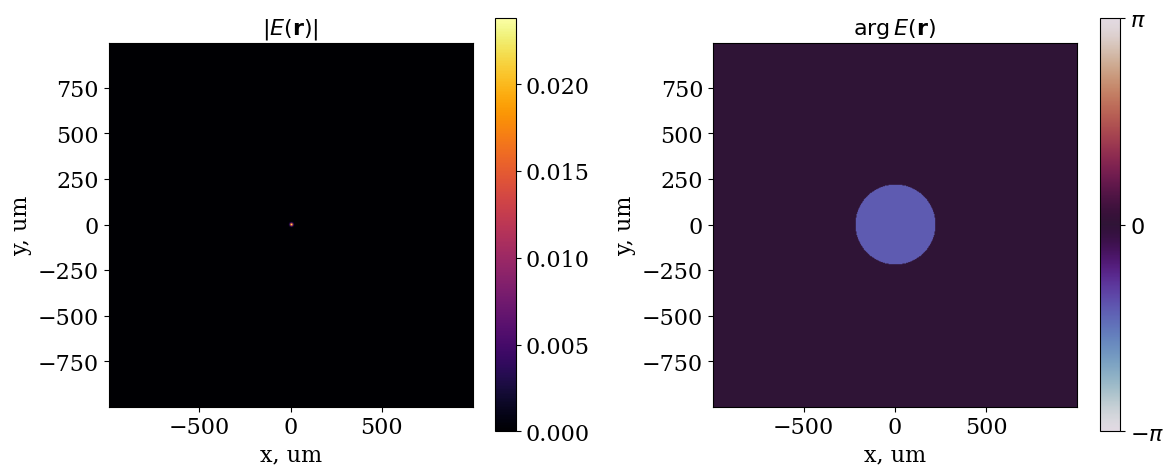

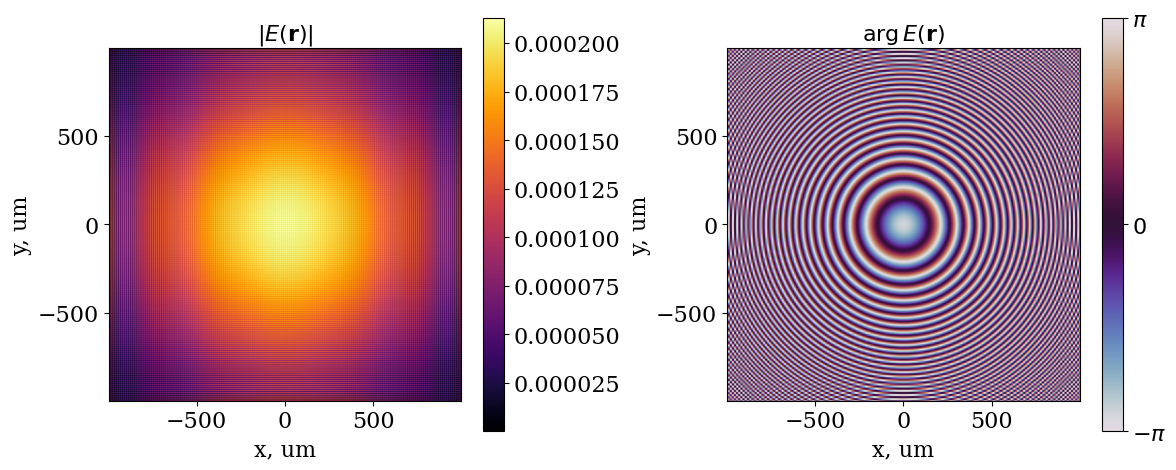

Время: 8.94 с


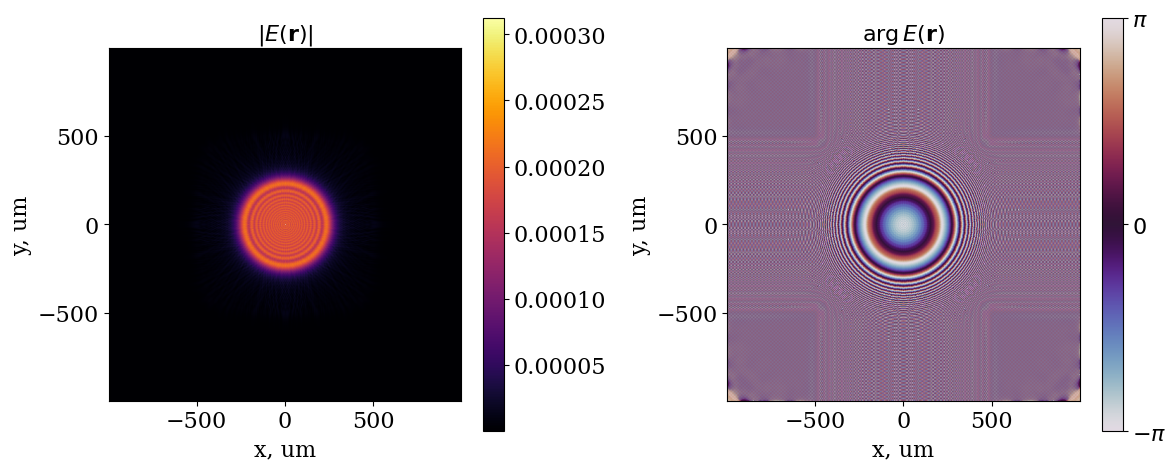

In [182]:

t0 = time.time()
'''
# Плоский спектр (равные веса)
dfl_gauss = generate_gaussian_source(
    xlamds=xlamds, shape=SHAPE, dgrid=DGRID,
    sigma_xy=sig_y, n_modes=50)
'''

# Гауссов спектр, lambda/delta_lambda = 1000
dfl_gauss = generate_gaussian_source(
    xlamds=xlamds, shape=SHAPE, dgrid=DGRID,
    sigma_xy=sig_y, n_modes=50, delta_lambda=1000)

plot_field(dfl_gauss)

dfl_gauss_ap = propagate_free_space(dfl_gauss, z=z1)

plot_field(dfl_gauss_ap)

aperture_ideal.apply(dfl_gauss_ap)

dfl_gauss_det = propagate_free_space(dfl_gauss_ap, z=z2)

print(f"Время: {time.time()-t0:.2f} с")

plot_field(dfl_gauss_det)
#plot_intensity(dfl_gauss_det)
#plot_coherence(dfl_gauss_det)
#plot_spectrum(dfl_gauss_det)

### SERVAL

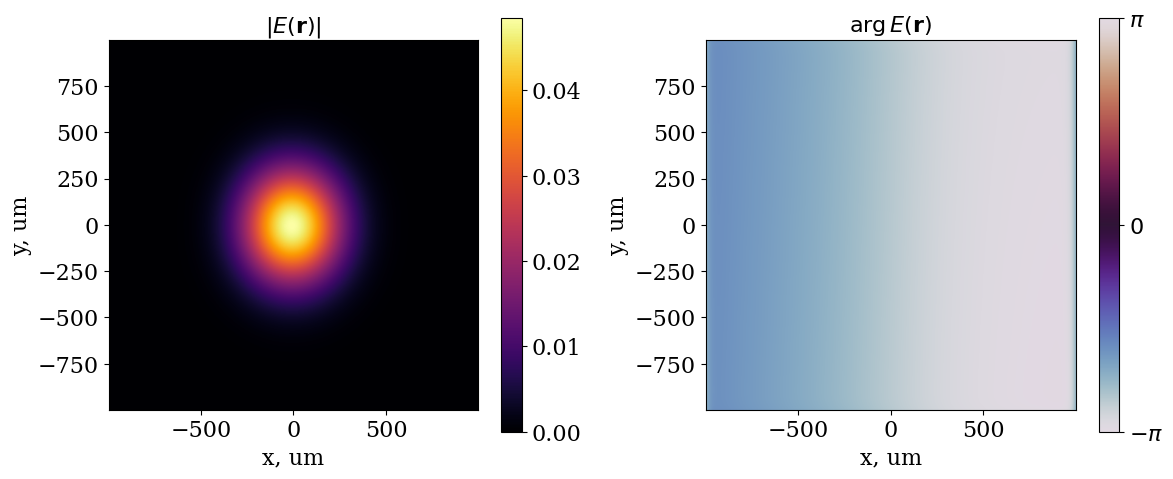

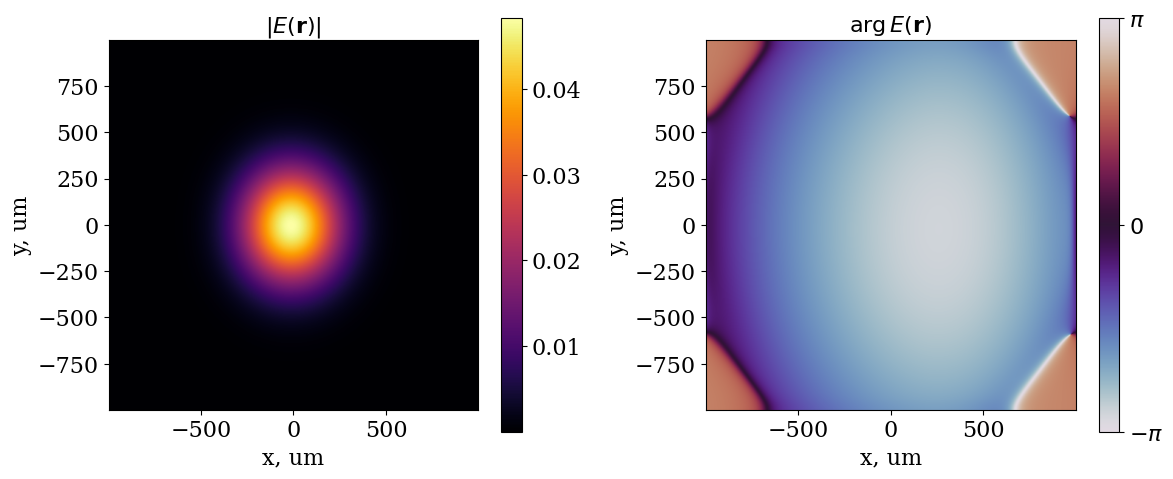

Время: 9.72 с
Интегральная когерентность ζ = 5834.92


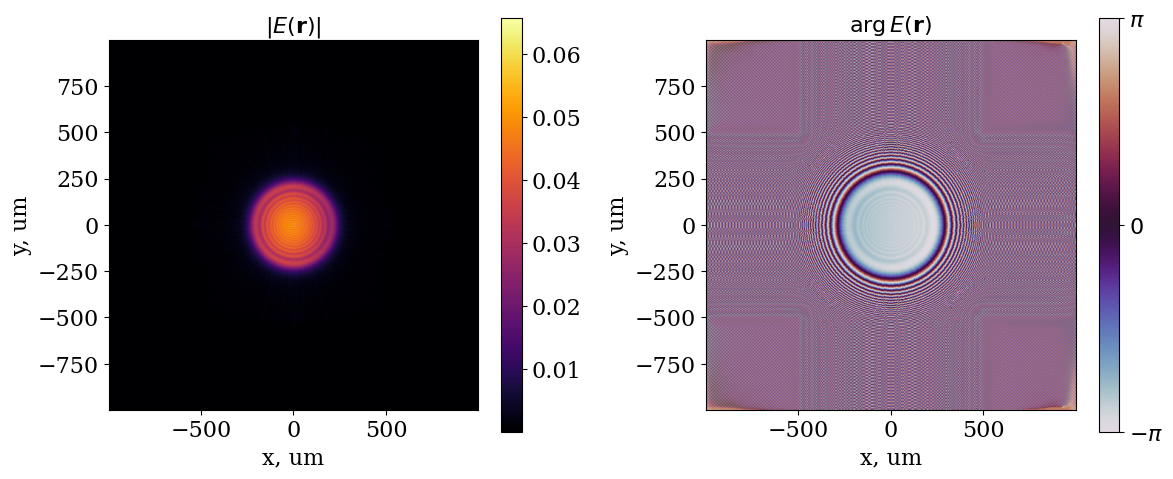

In [183]:
t0 = time.time()

# SERVAL с гауссовым спектром
dfl_serval = generate_serval(
    xlamds=xlamds, shape=SHAPE, dgrid=DGRID,
    sig_x=sig_x, sig_y=sig_y, sig_xp=sig_xp, sig_yp=sig_yp,
    n_modes=50, delta_lambda=1000)

plot_field(dfl_serval)

dfl_serval_ap = propagate_free_space(dfl_serval, z=z1)

plot_field(dfl_serval_ap)

aperture_ideal.apply(dfl_serval_ap)

dfl_serval_det = propagate_free_space(dfl_serval_ap, z=z2)

print(f"Время: {time.time()-t0:.2f} с")
print(f"Интегральная когерентность ζ = {dfl_serval_det.global_coherence():.2f}")

plot_field(dfl_serval_det)
#plot_intensity(dfl_serval_det)
#plot_coherence(dfl_serval_det)
#plot_spectrum(dfl_serval_det)
